In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("customer_churn_sample (1).csv")

df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


In [3]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType',
       'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets',
       'PaymentMethod', 'Churn'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        15 non-null     object 
 1   Gender            15 non-null     object 
 2   Age               15 non-null     int64  
 3   TenureMonths      15 non-null     int64  
 4   SubscriptionType  15 non-null     object 
 5   MonthlyCharges    15 non-null     float64
 6   TotalCharges      15 non-null     float64
 7   ContractType      15 non-null     object 
 8   SupportTickets    15 non-null     int64  
 9   PaymentMethod     15 non-null     object 
 10  Churn             15 non-null     object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.4+ KB


In [5]:
df.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,39.066667,18.800000,84.656667,2088.478667,2.533333
std,11.392144,14.333776,42.739521,2407.365767,1.922300
min,23.000000,2.000000,49.990000,99.980000,0.000000
25%,30.000000,7.000000,49.990000,449.910000,1.000000
50%,38.000000,15.000000,79.990000,1099.780000,2.000000
75%,47.000000,27.000000,114.990000,3209.730000,4.000000
max,60.000000,48.000000,149.990000,7199.520000,6.000000


In [6]:
df.isnull().sum()

CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64

In [7]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 46.67%


In [8]:
mrr_loss = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Monthly Revenue Loss (MRR): ${mrr_loss:.2f}")

Monthly Revenue Loss (MRR): $409.93


In [9]:
contract_churn = df.groupby("ContractType")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(contract_churn)

ContractType
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: Churn, dtype: float64


In [10]:
avg_monthly = df["MonthlyCharges"].mean()

avg_tenure = df["TenureMonths"].mean()

clv = avg_monthly * avg_tenure

print(f"Average Customer Lifetime Value (CLV): ${clv:.2f}")


Average Customer Lifetime Value (CLV): $1591.55


In [11]:
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(payment_churn)

PaymentMethod
Bank Transfer      0.000000
Credit Card       33.333333
Debit Card       100.000000
UPI               75.000000
Name: Churn, dtype: float64


In [12]:
df["TenureGroup"] = pd.cut(
    df["TenureMonths"],
    bins=[0,12,24,36,48],
    labels=["0-12","13-24","25-36","37-48"]
)

tenure_churn = df.groupby("TenureGroup")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_churn)

TenureGroup
0-12     100.0
13-24     20.0
25-36      0.0
37-48      0.0
Name: Churn, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_3852\712773662.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby("TenureGroup")["Churn"].apply(


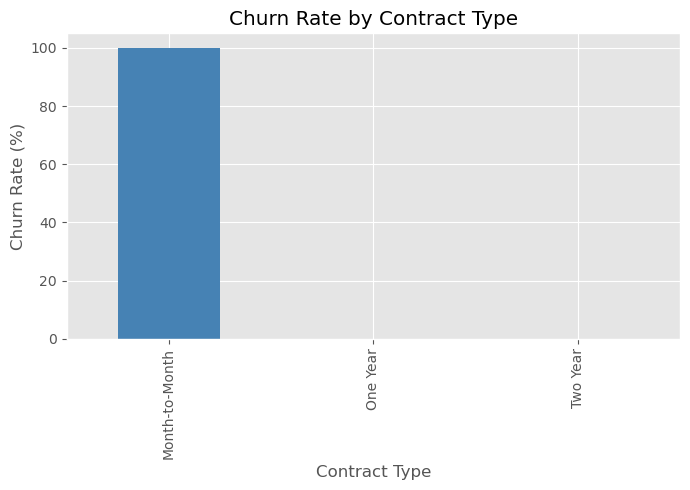

In [13]:
plt.figure(figsize=(7,5))

contract_churn.plot(kind="bar", color="steelblue")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig("contract_churn.png")

plt.show()

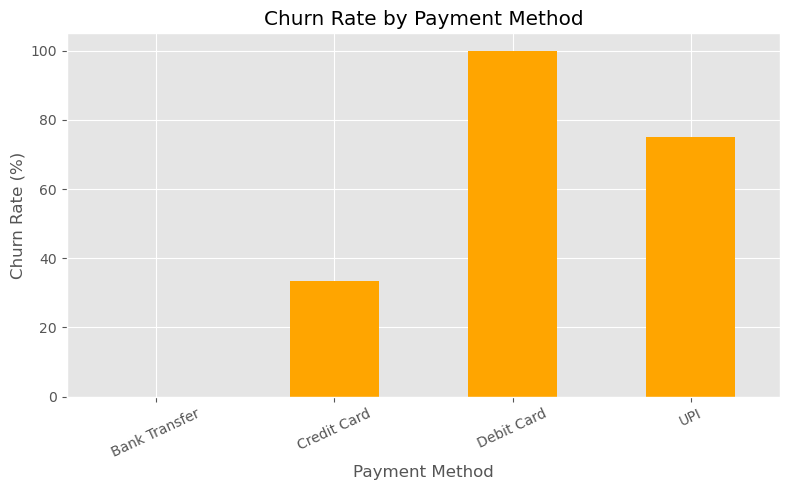

In [14]:
plt.figure(figsize=(8,5))

payment_churn.plot(kind="bar", color="orange")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig("payment_churn.png")

plt.show()

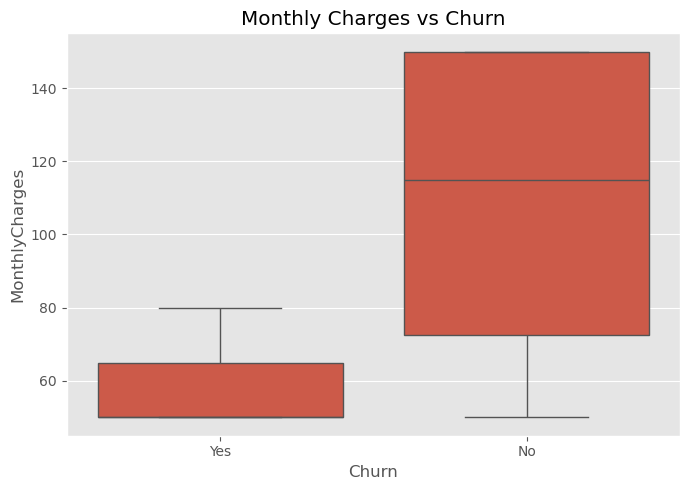

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.tight_layout()

plt.savefig("boxplot.png")

plt.show()

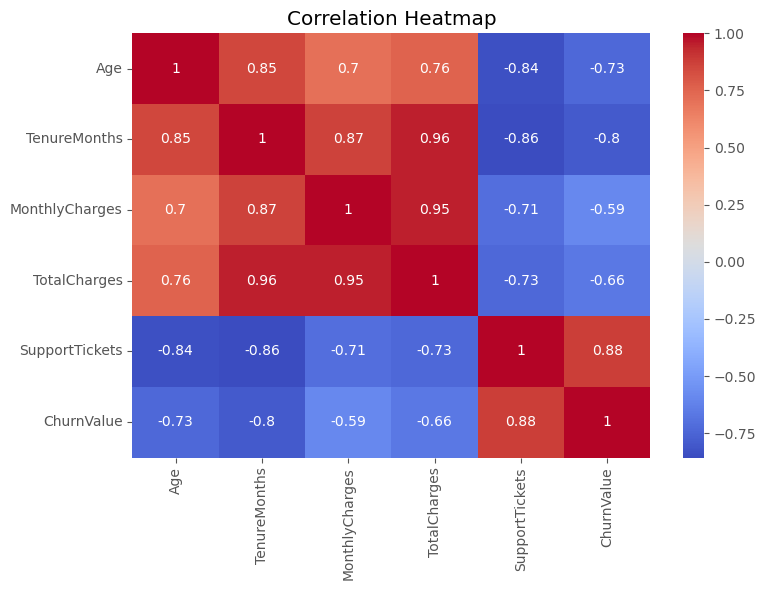

In [16]:
df["ChurnValue"] = df["Churn"].map({"Yes":1,"No":0})

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("heatmap.png")

plt.show()